In [84]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, ConcatDataset
from torch_geometric.loader import DataLoader as GeometricDataLoader
from torch_geometric.data import Data
from torch_geometric.utils import dense_to_sparse, subgraph, k_hop_subgraph
import torch_geometric.nn as pyg_nn
from scipy.io import loadmat, savemat
import os
import matplotlib.pyplot as plt


In [85]:
# Load saved beta data from mat file
analysis_type = 'N400'
curr_dir = os.getcwd()
datain_dir = os.path.join(os.getcwd(), 'datain')
datain_mat = loadmat(os.path.join(datain_dir, analysis_type + '_original_betas.mat'))
binatry_matrix_mat = loadmat(os.path.join(datain_dir, 'adjacency_matrix.mat'))
datain = datain_mat['data']
binatry_matrix = binatry_matrix_mat['adjacency_matrix']

datain = np.array(datain)          # shape: [nBeta, nTime, nChan, nSubject] (adjust as needed)
binatry_matrix = np.array(binatry_matrix)

# Parse shapes
nBeta     = datain.shape[0]
nTime     = datain.shape[1]
nChan     = datain.shape[2]
nSubject  = datain.shape[3]
print("Data shape:", datain.shape)

Data shape: (9, 201, 30, 40)


In [86]:
# ===========================================
# 2) Set device & convert adjacency
# ===========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
edge_index, _ = dense_to_sparse(torch.tensor(binatry_matrix, dtype=torch.float32))
print(device)

# ===========================================
# 3) Dataset builder
# ===========================================
def build_concat_dataset_for_beta(datain, beta_idx):
    """
    Build a ConcatDataset across all subjects for one beta index.
    `datain` is [nBeta, nTime, nChan, nSubject].
    Returns: ConcatDataset of length nSubject.
    """
    subject_datasets = []
    for s in range(nSubject):
        # Extract slice for one subject and one beta
        # shape: [nTime, nChan]
        single_beta_data = datain[beta_idx, :, :, s]

        # If each node is a channel and its feature dimension is time,
        # we might want single_beta_data to be [nChan, nTime].
        # If so, transpose here:
        single_beta_data = single_beta_data.T  # shape: [nChan, nTime]

        # For an autoencoder, features=labels
        x_tensor = torch.tensor(single_beta_data, dtype=torch.float32)
        x_tensor = x_tensor.unsqueeze(0)

        subject_datasets.append(TensorDataset(x_tensor, x_tensor))

    return ConcatDataset(subject_datasets)

cuda


In [87]:
# ===========================================
# 4) PyG Graph Dataset
# ===========================================
class EEGGraphDataset(torch.utils.data.Dataset):
    """
    Wraps a standard dataset so that each item is a PyG Data object:
      x -> node features (channels)
      edge_index -> adjacency
    """
    def __init__(self, eeg_data, edge_index):
        self.eeg_data = eeg_data
        self.edge_index = edge_index

    def __len__(self):
        return len(self.eeg_data)

    def __getitem__(self, idx):
        # item: (x, x) because it's autoencoder
        sample = self.eeg_data[idx]
        x = sample[0]  # shape: [nChan, nTime] (if you used transpose above)
        # Convert x -> float32, build PyG Data
        graph_data = Data(x=torch.tensor(x, dtype=torch.float32),
                          edge_index=self.edge_index)
        return graph_data


In [89]:
# ===========================================
# 5) Define GraphAutoencoder
# ===========================================
class GraphAutoencoder(nn.Module):
    def __init__(self, num_features, embedding_dim=64):
        """
        num_features = dimension of each node's feature vector.
                       If each channel is a node, and you pass
                       [nChan, nTime], then num_features = nTime.
        """
        super(GraphAutoencoder, self).__init__()
        # Example with two ARMAConv layers
        self.encoder_gcn1 = pyg_nn.ARMAConv(num_features, 128, 
                                            num_stacks=2, 
                                            num_layers=3,
                                            shared_weights=True)
        self.encoder_gcn2 = pyg_nn.ARMAConv(128, embedding_dim, 
                                            num_stacks=2, 
                                            num_layers=3,
                                            shared_weights=True)
        self.decoder_fc1 = nn.Linear(embedding_dim, 128)
        self.decoder_fc2 = nn.Linear(128, num_features)

    def encode(self, x, edge_index):
        x = torch.relu(self.encoder_gcn1(x, edge_index))
        latent = torch.relu(self.encoder_gcn2(x, edge_index))
        return latent
    
    def decode(self, latent):
        x = torch.relu(self.decoder_fc1(latent))
        reconstructed = self.decoder_fc2(x)
        return reconstructed
    
    def forward(self, x, edge_index):
        latent = self.encode(x, edge_index)
        reconstructed = self.decode(latent)
        return reconstructed

In [90]:
# ===========================================
# 6) Training and evaluation
# ===========================================
def train_model_all(model, train_loader, device, num_epochs):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.SmoothL1Loss()

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for batch_data in train_loader:
            #print("DEBUG x.shape in train loop:", tuple(batch_data.x.shape))
            batch_data = batch_data.to(device)
            optimizer.zero_grad()

            # Forward
            reconstructed = model(batch_data.x, batch_data.edge_index)
            loss = criterion(reconstructed, batch_data.x)

            # Backprop
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)
        if (epoch+1) % 50 == 0:
            print(f"Beta Model Training - Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")
    return model

def evaluation_model(model, data_sample, edge_index, device):
    """
    data_sample: shape [nChan, nTime], or [nTime, nChan],
                 whichever you used in training.
    Returns: (original_np, reconstructed_np, error_np)
    """
    model.eval()
    with torch.no_grad():
        x = torch.tensor(data_sample, dtype=torch.float32, device=device)
        eidx = edge_index.to(device)
        reconstructed = model(x, eidx)
    orig = x.cpu().numpy()
    recon = reconstructed.cpu().numpy()
    error = orig - recon
    return orig, recon, error


In [91]:

def activation_maximization(
    activation_func, input_shape, device,
    steps=400, lr=0.01, l2=1e-3, tv=1e-3):
    
    x = torch.randn(input_shape, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([x], lr=lr)
    
    for step in range(steps):
        optimizer.zero_grad()
        # Compute activation
        activation = activation_func(x)
        
        # Compute loss = negative activation + regularization
        loss = -activation
        loss += l2 * torch.mean(x**2)
        
        # Total Variation (TV) regularization
        dx = x[1:, :] - x[:-1, :]
        dy = x[:, 1:] - x[:, :-1]
        tv_loss = dx.abs().mean() + dy.abs().mean()
        loss += tv * tv_loss
    
        loss.backward()
        optimizer.step()
    
        if (step+1) % 50 == 0:
            print(f"Step {step+1} | loss {loss.item():.4f} | activation {activation.item():.4f}")
    
    return x.detach().cpu()

def apply_activation_maximization(
    model, edge_index, nChan, nTime,
    device, latent_ind, steps=400, lr=0.01,
    l2=1e-3, tv=1e-3):
    
    model = model.to(device)
    model.eval()
    eidx = edge_index.to(device)
    
    # Define activation function
    def activation_func(x):
        latent = model.encode(x, eidx)
        if latent_ind == None:
            act = latent.mean()
        else:
            act = latent[:, latent_ind].mean()
        return act
    
    x = activation_maximization(
        activation_func=activation_func,
        input_shape=(nChan, nTime),
        device=device, steps=steps,
        lr=lr, l2=l2, tv=tv)
    
    return x


In [92]:
num_features = nTime   # if each channel is a node, and feature vector = [nTime]
num_epochs   = 200     # number of training - set as needed
batch_size   = 4       # dataset/batch to update hyperparameters
embedding_dim = 32     # latent dimension size

models = []
all_x_am = []
all_whole_am = []

for iBeta in range(nBeta):
    print(f"\n=== Building dataset/model for Beta {iBeta} ===")
    # Build dataset & loader
    full_dataset_i  = build_concat_dataset_for_beta(datain, iBeta)
    graph_dataset_i = EEGGraphDataset(full_dataset_i, edge_index)
    full_loader_i   = GeometricDataLoader(graph_dataset_i, batch_size=batch_size, shuffle=True)

    # Init model & train
    model_i = GraphAutoencoder(num_features=num_features, embedding_dim=embedding_dim)
    model_i = train_model_all(model_i, full_loader_i, device, num_epochs=num_epochs)
    models.append(model_i)
    
    all_whole_am.append(np.array(apply_activation_maximization(
        model=model_i, edge_index=edge_index,
        nChan=nChan, nTime=nTime, device=device,
        latent_ind=None, steps=400,
        lr=0.01, l2=1e-3, tv=1e-3)))
    
    x_am_list = []
    for latent_idx in range(embedding_dim):
        print(f"\n=== Activation Maximization for Beta {iBeta}, Latent {latent_idx} ===")
        x_am = apply_activation_maximization(
            model=model_i, edge_index=edge_index,
            nChan=nChan, nTime=nTime, device=device,
            latent_ind=latent_idx, steps=400,
            lr=0.01, l2=1e-3, tv=1e-3) # shape: [nChan, nTime]
        x_am_list.append(np.array(x_am))
    
    all_x_am.append(np.array(x_am_list))
    
all_x_am = np.stack(all_x_am, axis=0)  # shape: [nBeta, embedding_dim, nChan, nTime]
all_whole_am = np.stack(all_whole_am, axis=0)  # shape: [nBeta, nChan, nTime]
        
        



=== Building dataset/model for Beta 0 ===


C:\Users\86136\AppData\Local\Temp\ipykernel_36524\1382389434.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  graph_data = Data(x=torch.tensor(x, dtype=torch.float32),


Beta Model Training - Epoch [50/200], Loss: 0.1975
Beta Model Training - Epoch [100/200], Loss: 0.1852
Beta Model Training - Epoch [150/200], Loss: 0.1572
Beta Model Training - Epoch [200/200], Loss: 0.1519
Step 50 | loss -10.6030 | activation 10.6070
Step 100 | loss -20.2794 | activation 20.2845
Step 150 | loss -30.3284 | activation 30.3351
Step 200 | loss -40.2690 | activation 40.2780
Step 250 | loss -50.0881 | activation 50.0999
Step 300 | loss -59.8097 | activation 59.8247
Step 350 | loss -69.4538 | activation 69.4725
Step 400 | loss -79.0354 | activation 79.0583

=== Activation Maximization for Beta 0, Latent 0 ===
Step 50 | loss -12.6794 | activation 12.6831
Step 100 | loss -25.1400 | activation 25.1447
Step 150 | loss -37.8363 | activation 37.8426
Step 200 | loss -50.4580 | activation 50.4664
Step 250 | loss -62.9467 | activation 62.9577
Step 300 | loss -75.3398 | activation 75.3538
Step 350 | loss -87.6897 | activation 87.7073
Step 400 | loss -100.0032 | activation 100.0248

==

In [93]:
# save importances results
save_dir = os.path.join(curr_dir, analysis_type, 'Activation Maximization')
os.makedirs(save_dir, exist_ok=True)

am_res = {'all_x_am': all_x_am}
am_whole_res = {'all_whole_am': all_whole_am}

savemat(os.path.join(save_dir, 'all_x_am.mat'), am_res)
savemat(os.path.join(save_dir, 'all_whole_am.mat'), am_whole_res)

In [94]:
# Visualize importances of subject masking
save_dir = os.path.join(curr_dir, analysis_type, 'Activation Maximization')
am_res = loadmat(os.path.join(save_dir, 'all_x_am.mat'))
am_whole_res = loadmat(os.path.join(save_dir, 'all_whole_am.mat'))
all_x_am = am_res['all_x_am']  # shape: [nBeta, embedding_dim, nChan, nTime]
all_whole_am = am_whole_res['all_whole_am']  # shape: [nBeta, nChan, nTime]
nBeta, embedding_dim, nChan, nTime = all_x_am.shape

In [95]:
# get channel names
chanlocs_mat = loadmat(os.path.join(datain_dir, 'limo_chanlocs.mat'))
expected_chanlocs = chanlocs_mat['expected_chanlocs']
channel_names = [loc[0] for loc in expected_chanlocs['labels'][0]]

In [96]:
# Whole latent prototype and prototype reconstruction result visualization

save_whole_dir = os.path.join(save_dir, 'Whole_Latent')
os.makedirs(save_whole_dir, exist_ok=True)

all_whole_am = all_whole_am**2

global_max = np.max(all_whole_am)
global_min = 0.0

for iBeta in range(nBeta):
    am = all_whole_am[iBeta]  # shape: [nChan, nTime]
    plt.figure(figsize=(16, 13))
    plt.imshow(am, aspect='auto', cmap='Reds', vmin=global_min, vmax=global_max)
    plt.colorbar(label='Activation Maximization Value')
    plt.xlabel('Time')
    plt.ylabel('Channels')
    plt.yticks(ticks=np.arange(nChan), labels=np.arange(1, nChan+1))
    plt.title(f'Beta {iBeta+1} - Global Activation Maximization')
    plt.tight_layout()
    plt.savefig(os.path.join(save_whole_dir, f'Beta_{iBeta+1}_whole_latent_am.png'))
    plt.close()
    
    channel_energy = np.mean(am, axis=1)  # shape: [nChan]
    plt.figure(figsize=(16, 13))
    plt.bar(np.arange(nChan), channel_energy)
    plt.xlabel('Channels')
    plt.ylabel('Mean Squared Activation Maximization Value')
    plt.ylim(0, global_max)
    plt.xticks(ticks=np.arange(nChan), labels=np.arange(1, nChan+1))
    plt.title(f'Beta {iBeta+1} - Channel Energy')
    plt.tight_layout()
    plt.savefig(os.path.join(save_whole_dir, f'Beta_{iBeta+1}_whole_latent_channel.png'))
    plt.close()
    

In [97]:
# Heatmap for each beta and all latent dimensions
save_heatmap_dir = os.path.join(save_dir, 'Channel_Time_Heatmaps')
os.makedirs(save_heatmap_dir, exist_ok=True)
all_x_am_energy = all_x_am**2

global_max = all_x_am_energy.mean(axis=1).max()
global_min = all_x_am_energy.mean(axis=1).min()

for iBeta in range(nBeta):
    value = all_x_am_energy[iBeta].mean(axis=0)  # shape: [nChan, nTime]
    
    plt.figure(figsize=(16,13))
    plt.imshow(value, aspect='auto', cmap='Reds', vmin=global_min, vmax=global_max)
    plt.colorbar(label='Activation Maximization Value')
    plt.yticks(ticks=np.arange(nChan), labels=np.arange(1, nChan+1))
    plt.xlabel('Time')
    plt.ylabel('Channels')
    plt.title(f'Beta {iBeta+1} - Activation Maximization Heatmap')
    plt.tight_layout()
    plt.savefig(os.path.join(save_heatmap_dir, f'Beta_{iBeta+1}_heatmap.png'))
    plt.close()

In [98]:
# Heatmap for each latent dimension of each beta

global_max = all_x_am_energy.max()
global_min = all_x_am_energy.min()

for iBeta in range(nBeta):
    save_heatmap_subdir = os.path.join(save_heatmap_dir, f'Beta_{iBeta+1}')
    os.makedirs(save_heatmap_subdir, exist_ok=True)
    
    for latent_idx in range(embedding_dim):
        value = all_x_am_energy[iBeta, latent_idx]  # shape: [nChan, nTime]
        
        plt.figure(figsize=(16,13))
        plt.imshow(value, aspect='auto', cmap='Reds', vmin=global_min, vmax=global_max)
        plt.colorbar(label='Activation Maximization Value')
        plt.yticks(ticks=np.arange(nChan), labels=np.arange(1, nChan+1))
        plt.xlabel('Time')
        plt.ylabel('Channels')
        plt.title(f'Beta {iBeta+1} - Latent Dimension {latent_idx+1} Activation Maximization Heatmap')
        plt.tight_layout()
        plt.savefig(os.path.join(save_heatmap_subdir, f'Latent_{latent_idx+1}_heatmap.png'))
        plt.close()
    

In [99]:
# Compare original, reconstructed and AM per beta
save_compare_dir = os.path.join(save_dir, 'AM_Compare_Per_Channel')
os.makedirs(save_compare_dir, exist_ok=True)

reon_mat = loadmat(os.path.join(datain_dir, analysis_type + '_reconstructed_betas.mat'))
recon_data = reon_mat['recon_betas']  # shape: [nBeta, nTime, nChan, nSubject]
print("recon_data shape:", recon_data.shape)
am_mean = all_x_am.mean(axis=1)  # shape: [nBeta, nChan, nTime]
print("am_mean shape:", am_mean.shape)
print("datain shape:", datain.shape) # shape: [nBeta, nTime, nChan, nSubject]

for iBeta in range(nBeta):
    save_compare_subdir = os.path.join(save_compare_dir, f'Beta_{iBeta+1}')
    os.makedirs(save_compare_subdir, exist_ok=True)
    
    am_beta = am_mean[iBeta]  # shape: [nChan, nTime]
    recon_beta = recon_data[iBeta].mean(axis=2).T  # shape: [nChan, nTime]
    orig_beta = datain[iBeta].mean(axis=2).T  # shape: [nChan, nTime]
    
    global_max = min(am_beta.max(), recon_beta.max(), orig_beta.max())
    global_min = max(am_beta.min(), recon_beta.min(), orig_beta.min())
    
    for ch in range(nChan):
        plt.figure(figsize=(16,13))
        plt.plot(np.arange(nTime), am_beta[ch], label='Activation Maximization')
        plt.plot(np.arange(nTime), recon_beta[ch], label='Reconstructed')
        plt.plot(np.arange(nTime), orig_beta[ch], label='Original')
        plt.ylim(global_min, global_max)
        plt.xlabel('Time')
        plt.ylabel('Beta Value')
        plt.title(f'Beta {iBeta+1} - Channel {ch+1} Comparison')
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(save_compare_subdir, f'Channel_{ch+1}_comparison.png'))
        plt.close()

recon_data shape: (9, 201, 30, 40)
am_mean shape: (9, 30, 201)
datain shape: (9, 201, 30, 40)


In [100]:
# Visualize latent time energy to discover which latent dimensions focus on which time periods

save_energy_dir = os.path.join(save_dir, 'Latent_Time_Energy')
os.makedirs(save_energy_dir, exist_ok=True)

time_imp_per_beta = np.mean(all_x_am**2, axis=2)  # shape: [nBeta, embedding_dim, nTime]
print("time_imp_per_beta shape:", time_imp_per_beta.shape)

global_max = time_imp_per_beta.max()
global_min = 0.0

for iBeta in range(nBeta):
    plt.figure(figsize=(16,13))
    plt.imshow(time_imp_per_beta[iBeta], aspect='auto', cmap='Reds', vmin=global_min, vmax=global_max)
    plt.colorbar(label='Latent Time Energy')
    plt.yticks(ticks=np.arange(embedding_dim), labels=np.arange(1, embedding_dim+1))
    plt.xlabel('Time')
    plt.ylabel('Latent Dimensions')
    plt.title(f'Beta {iBeta+1} - Latent Time Energy')
    plt.tight_layout()
    plt.savefig(os.path.join(save_energy_dir, f'Beta_{iBeta+1}_latent_time_energy.png'))
    plt.close()


time_imp_per_beta shape: (9, 32, 201)


In [101]:
# Visualize latent channel energy to discover which latent dimensions focus on which channels
save_energy_dir2 = os.path.join(save_dir, 'Latent_Channel_Energy')
os.makedirs(save_energy_dir2, exist_ok=True)

channel_imp_per_beta = np.mean(all_x_am**2, axis=3)  # shape: [nBeta, embedding_dim, nChan]
global_max = channel_imp_per_beta.max()
global_min = 0.0

for iBeta in range(nBeta):
    plt.figure(figsize=(16,13))
    plt.imshow(channel_imp_per_beta[iBeta], aspect='auto', cmap='Reds', vmin=global_min, vmax=global_max)
    plt.colorbar(label='Latent Channel Energy')
    plt.xticks(ticks=np.arange(nChan), labels=np.arange(1, nChan+1))
    plt.yticks(ticks=np.arange(embedding_dim), labels=np.arange(1, embedding_dim+1))
    plt.xlabel('Channels')
    plt.ylabel('Latent Dimensions')
    plt.title(f'Beta {iBeta+1} - Latent Channel Energy')
    plt.tight_layout()
    plt.savefig(os.path.join(save_energy_dir2, f'Beta_{iBeta+1}_latent_channel_energy.png'))
    plt.close()

In [102]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.colors import BoundaryNorm
from collections import defaultdict

save_cluster_dir = os.path.join(save_dir, 'Clustering_Latent_Dimensions')
os.makedirs(save_cluster_dir, exist_ok=True)

e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


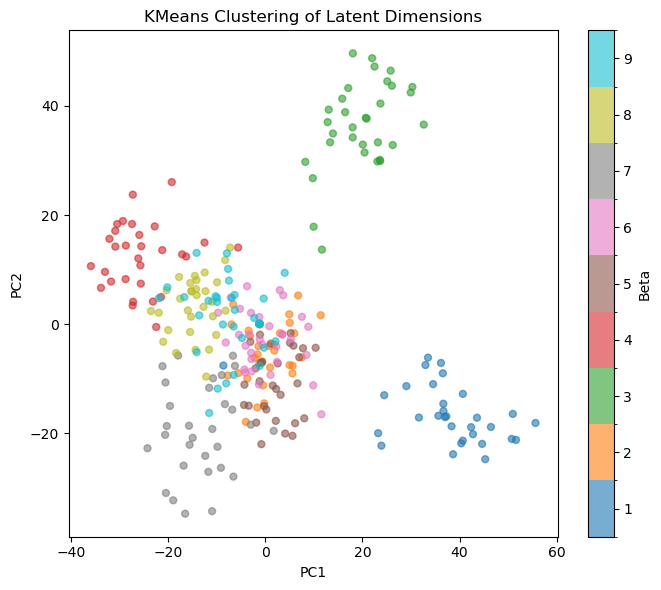

In [103]:
# Visualize clustering of latent dimensions across betas

# Prepare data for clustering
nBeta, embedding_dim, nChan, nTime = all_x_am.shape
units = all_x_am.reshape(nBeta*embedding_dim, nChan*nTime)  # shape: [nBeta*embedding_dim, nChan*nTime]

# label ids for each unit
beta_ids = np.repeat(np.arange(nBeta), embedding_dim)  # shape: [nBeta*embedding_dim]
latent_ids = np.tile(np.arange(embedding_dim), nBeta)  # shape: [nBeta*embedding_dim]

# Standardize data
scaler = StandardScaler()
units_std = scaler.fit_transform(units)

# perform PCA to reduce dimensionality
pca = PCA(n_components=10)
units_pca = pca.fit_transform(units_std)

# KMeans clustering
k = nBeta  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=52, n_init='auto')
cluster_labels = kmeans.fit_predict(units_pca)

# PCA for visualization
pca2 = PCA(n_components=2)
units_2d = pca2.fit_transform(units_pca)

# Plot clustering results
plt.figure(figsize=(7, 6))
cmap = plt.get_cmap('tab10', nBeta)
boundaries = np.arange(0.5, nBeta + 1.5, 1)
norm = BoundaryNorm(boundaries, cmap.N)

scatter = plt.scatter(units_2d[:, 0], units_2d[:, 1], c=beta_ids+1, cmap=cmap, norm=norm, alpha=0.6, s=25)

cbar = plt.colorbar(scatter)
cbar.set_label("Beta")
cbar.set_ticks(np.arange(1, nBeta+1, 1))
cbar.set_ticklabels(np.arange(1, nBeta+1, 1))

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering of Latent Dimensions")
plt.tight_layout()
plt.savefig(os.path.join(save_cluster_dir, 'KMeans_clustering_latent_dimensions.png'))
plt.show()
plt.close()

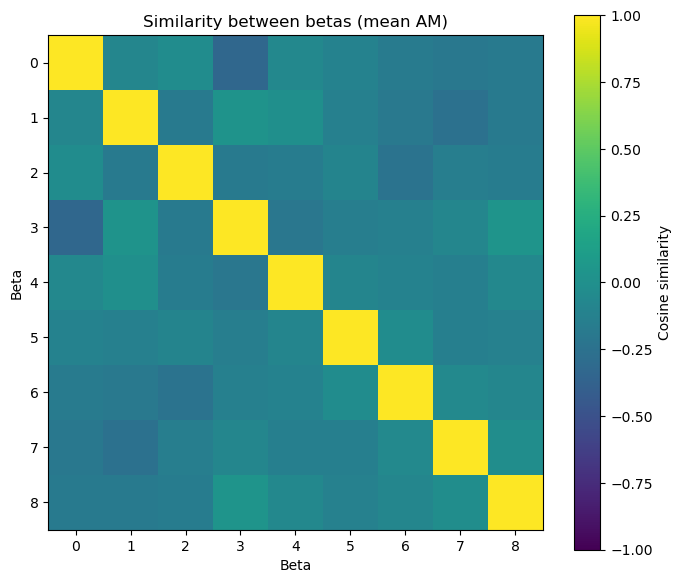

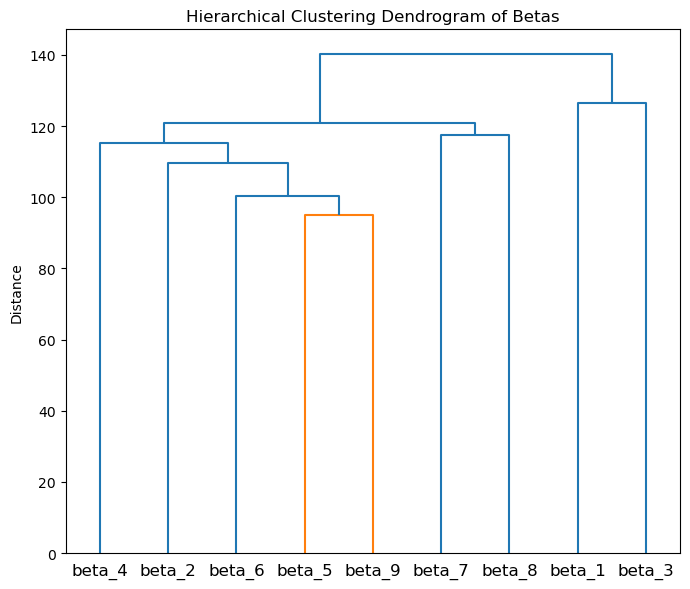

In [104]:
beta_mean = all_x_am.mean(axis=1)  # shape: [nBeta, nChan, nTime]
# flatten and standardize for clustering
x_beta = beta_mean.reshape(nBeta, nChan*nTime)  # shape: [nBeta, nChan*nTime]
x_beta_std = scaler.fit_transform(x_beta)
# Compute cosine similarity
cos_sim = cosine_similarity(x_beta_std)

# Plot heatmap of cosine similarity
plt.figure(figsize=(7, 6))
x_sim = plt.imshow(cos_sim, vmin=-1, vmax=1)
plt.colorbar(x_sim, label='Cosine similarity')
plt.xlabel('Beta')
plt.ylabel('Beta')
plt.title('Similarity between betas (mean AM)')
plt.tight_layout()
plt.savefig(os.path.join(save_cluster_dir, 'Beta_similarity_heatmap.png'))
plt.show()
plt.close()


# plot hierarchical clustering dendrogram of betas
link = linkage(x_beta_std, method='ward')
plt.figure(figsize=(7, 6))
dendrogram(link, labels=[f'beta_{i+1}' for i in range(nBeta)])
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram of Betas')
plt.tight_layout()
plt.savefig(os.path.join(save_cluster_dir, 'Beta_hierarchical_dendrogram.png'))
plt.show()
plt.close()


In [105]:
# Visualize clustering of latent dimensions within each beta

for iBeta in range(nBeta):
    x_beta = all_x_am[iBeta].reshape(embedding_dim, nChan * nTime)

    x_beta_std = scaler.fit_transform(x_beta)
    pca_beta = PCA(n_components=2)
    x_beta_2d = pca_beta.fit_transform(x_beta_std)

    km_beta = KMeans(n_clusters=5, random_state=52, n_init='auto')
    cluster_one_beta = km_beta.fit_predict(x_beta_std)

    plt.figure(figsize=(7, 6))
    plt.scatter(x_beta_2d[:, 0], x_beta_2d[:, 1], c=cluster_one_beta, cmap='tab10')
    for d in range(embedding_dim):
        plt.text(x_beta_2d[d, 0], x_beta_2d[d, 1], str(d), fontsize=9)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'Latent units clustering within beta {iBeta+1}')
    plt.tight_layout()
    #plt.show()
    plt.savefig(os.path.join(save_cluster_dir, f'Beta_{iBeta+1}_latent_clustering.png'))
    plt.close()


e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

e:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


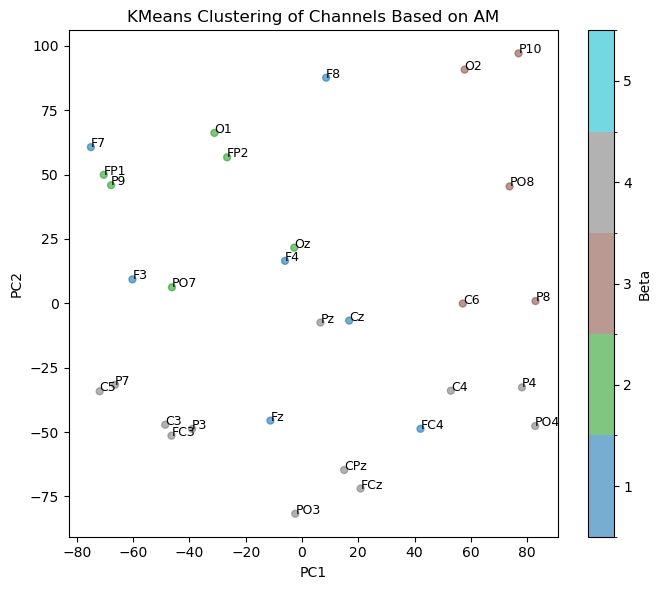


=== Cluster 0 ===
  Channel 17  ->  Fz
  Channel 18  ->  F4
  Channel 20  ->  FC4

=== Cluster 1 ===
  Channel  2  ->  F3
  Channel  3  ->  F7
  Channel 19  ->  F8
  Channel 22  ->  Cz

=== Cluster 2 ===
  Channel  1  ->  FP1
  Channel  9  ->  P9
  Channel 10  ->  PO7
  Channel 12  ->  O1
  Channel 13  ->  Oz
  Channel 16  ->  FP2

=== Cluster 3 ===
  Channel 24  ->  C6
  Channel 26  ->  P8
  Channel 27  ->  P10
  Channel 28  ->  PO8
  Channel 30  ->  O2

=== Cluster 4 ===
  Channel  4  ->  FC3
  Channel  5  ->  C3
  Channel  6  ->  C5
  Channel  7  ->  P3
  Channel  8  ->  P7
  Channel 11  ->  PO3
  Channel 14  ->  Pz
  Channel 15  ->  CPz
  Channel 21  ->  FCz
  Channel 23  ->  C4
  Channel 25  ->  P4
  Channel 29  ->  PO4


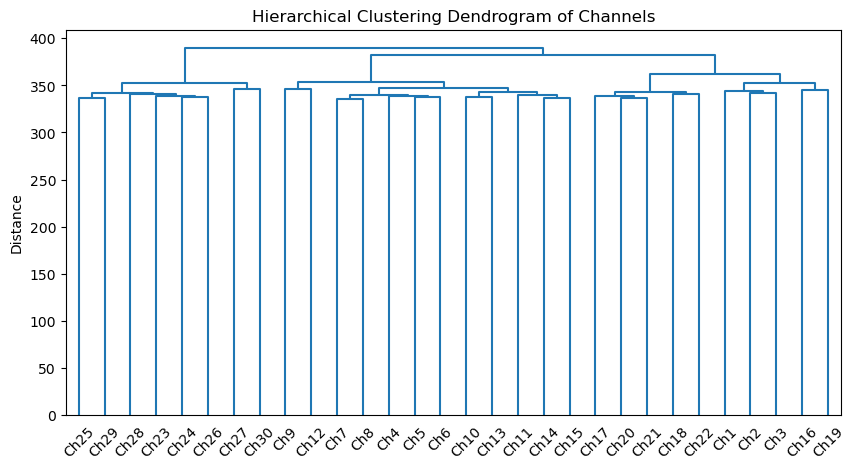

In [106]:
# reshpe for channel clustering
x_chan = all_x_am.transpose(2, 0, 1, 3).reshape(nChan, -1)

scaler = StandardScaler()
x_chan_std = scaler.fit_transform(x_chan)

k = 5  # according to the brain regions
km = KMeans(n_clusters=k, random_state=0, n_init='auto')
chan_labels = km.fit_predict(x_chan_std)

pca = PCA(n_components=2)
x_chan_2d = pca.fit_transform(x_chan_std)

cmap = plt.get_cmap('tab10', k)
boundaries = np.arange(0.5, k + 1.5, 1)
norm = BoundaryNorm(boundaries, cmap.N)



plt.figure(figsize=(7, 6))
scatter = plt.scatter(x_chan_2d[:, 0], x_chan_2d[:, 1], c=chan_labels, cmap=cmap, norm=norm, alpha=0.6, s=25)

cbar = plt.colorbar(scatter)
cbar.set_label("Beta")
cbar.set_ticks(np.arange(1, k+1, 1))
cbar.set_ticklabels(np.arange(1, k+1, 1))

for ch in range(nChan):
    name = channel_names[ch]
    plt.text(x_chan_2d[ch, 0], x_chan_2d[ch, 1], name, fontsize=9)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clustering of Channels Based on AM')
plt.tight_layout()
plt.savefig(os.path.join(save_cluster_dir, 'KMeans_clustering_channels.png'))
plt.show()
plt.close()


# group channel indices by cluster
clusters = defaultdict(list)
for ch_idx, cl in enumerate(chan_labels):
    clusters[cl].append(ch_idx)

# print channels in each cluster
for cl in range(k):
    print(f"\n=== Cluster {cl} ===")
    ch_list = clusters[cl]
    ch_list = sorted(ch_list)
    for ch_idx in ch_list:
        name = channel_names[ch_idx]
        print(f"  Channel {ch_idx+1:2d}  ->  {name}")
    


link = linkage(x_chan_std, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(link, labels=[f"Ch{c+1}" for c in range(nChan)])
plt.title("Hierarchical Clustering Dendrogram of Channels")
plt.ylabel("Distance")
plt.show()
